In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE,VPSDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical, Uniform
from probjax.utils.odeint import _odeint

/root/miniconda3/envs/probjax/lib/python3.10/site-packages/jax/_src/api_util.py:174: SyntaxWarning: Jitted function has static_argnums=(3, 4), but only accepts 4 positional arguments. This warning will be replaced by an error after 2022-08-20 at the earliest.
  warnings.warn(f"Jitted function has {argnums_name}={argnums}, "


In [ ]:
def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    # predator and prey are swapped
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey

In [ ]:
dt = 0.1
time_start = 0. 
time_end = 5.
eval_time_points = int(time_end / dt)
ts = jnp.linspace(time_start, time_end, eval_time_points)

In [ ]:
prior = Uniform(jnp.array([0.5]), jnp.array([3.]))

In [5]:
def model(key, ode_method="rk4", ode_ts_grid=ts):
    key_theta0, key_theta1, key_theta2, key_theta3, key_predator, key_prey = jrandom.split(key, 6)
    
    theta0 = rv(prior, name="theta0")(key_theta0)
    theta1 = rv(prior, name="theta1")(key_theta1)
    theta2 = rv(prior, name="theta2")(key_theta2)
    theta3 = rv(prior, name="theta3")(key_theta3)
    
    predator, prey = _odeint(drift_lotka_volterra, (1., 0.5), ode_ts_grid, theta0, theta1, theta2, theta3, method=ode_method)

    
    x0 = rv(Independent(Normal(predator, 0.1),1), name="x0")(key_predator)
    x1 = rv(Independent(Normal(prey, 0.1),1), name="x1")(key_prey)
    
    thetas = jnp.concatenate([theta0, theta1, theta2, theta3], axis=0)
    xs = jnp.concatenate([x0, x1], axis=0)
    return thetas, xs 


In [6]:
thetas, xs = jax.vmap(model)(jax.random.split(jax.random.PRNGKey(0), 10000))

In [7]:
xs.shape

(10000, 100)

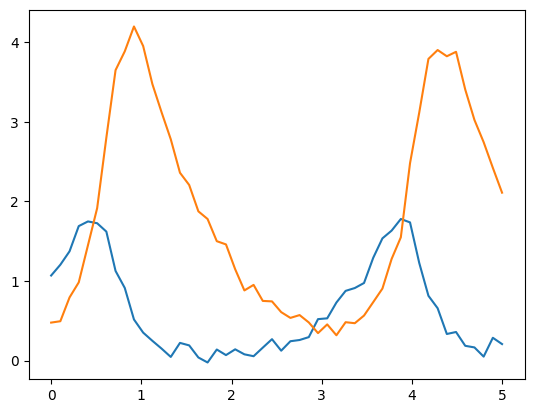

In [8]:
x1,x2 = jnp.split(xs[0], 2)
plt.plot(ts, x1)
plt.plot(ts, x2)

In [52]:

# VPSDE 
T = 1.
T_min = 1e-3
beta_min = 0.01
beta_max = 10.

p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
sde = VPSDE(p0, beta_min=beta_min , beta_max=beta_max)

def output_scale_fn(t, x):
    scale = sde.marginal_stddev(t, jnp.ones_like(x))
    return (1/scale * x).reshape(x.shape)

def weight_fn(t):
    return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-4

In [55]:
# s(theta| x_t, x_t+1)
# x_t R^2, x_t+1 R^2
hidden_dim = 100
activation = jax.nn.gelu
num_hidden = 6
layer_norm = True

def score_net(a, theta, x_t0, x_t1):
    
    context = jnp.concatenate([x_t0, x_t1], axis=-1) 

    time_embedding = GaussianFourierEmbedding(hidden_dim)(a[..., None])
    
    h1 = hk.Linear(hidden_dim//2)(context)
    h2 = hk.Linear(hidden_dim - hidden_dim//2)(theta)
    
    h = activation(jnp.concatenate([h1, h2], axis=-1) + time_embedding)

    for _ in range(num_hidden - 1):
        h_new = hk.Linear(hidden_dim)(h)
        h_new += time_embedding
        h = activation(h_new)

        if layer_norm:
            h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)

    out = hk.Linear(theta.shape[-1])(h)
    return out.reshape(theta.shape)


In [56]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10), thetas[:10], jnp.ones((10, 2)), x_t1=jnp.ones((10, 2))) # Initialize the parameters of the model

In [57]:

def generate_step(key):
    key_batch, key_x0, key_x1, n0, n1 = jax.random.split(key, 5)
    
    theta = prior.sample(key_batch, (4,))[:,0]
    prey_t0 = jax.random.uniform(key_x0, (1,), minval=0., maxval=8.)
    predator_t0 = jax.random.uniform(key_x1, (1,), minval=0., maxval=8.)
    
    prey_t0_start = prey_t0.copy()
    predator_t0_start = predator_t0.copy()
    
    steps = 1
    
    for _ in range(steps):
        dprey_t1, dpredator_t1 = drift_lotka_volterra(0., (prey_t0_start, predator_t0_start), theta[0], theta[1], theta[2], theta[3])
        prey_t1 = prey_t0_start + dprey_t1 * dt / steps
        predator_t1 = predator_t0_start + dpredator_t1 * dt / steps
        preyt0_start = prey_t1
        predator_t0_start = predator_t1
    
    x_t0 = jnp.concatenate([prey_t0, predator_t0], axis=0)
    x_t1 = jnp.concatenate([prey_t1, predator_t1], axis=0)
    
    x_t0 = x_t0 + jax.random.normal(n1, (2,)) * 0.1
    x_t1 = x_t1 + jax.random.normal(n0, (2,)) * 0.1
    
    return theta, x_t0, x_t1

@partial(jax.jit, static_argnums=(1,))
def generate_data(key, n):
    keys = jax.random.split(key, n)
    return jax.vmap(generate_step)(keys)

In [58]:
theta_batch, x_t0, x_t1 = generate_data(jax.random.PRNGKey(0), 10)

In [59]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10),theta_batch, x_t0, x_t1) # Initialize the parameters of the model

In [61]:


def loss_fn(params, key, batch_size= 5128):

    rng_time, rng_data, rng_sample = jax.random.split(key, 3)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size,), minval=T_min, maxval=1.0)
    theta_batch, x_t0, x_t1 = generate_data(rng_data, batch_size) # n, T_max, 1
    

    # Forward diffusion, do not perturb conditioned data
    loss = denoising_score_matching_loss(params, rng_sample, times, theta_batch, None, model_fn= model_fn, mean_fn=sde.marginal_mean, std_fn = sde.marginal_stddev, weight_fn=weight_fn, x_t0=x_t0, x_t1=x_t1, axis=-1)
    
    return loss


In [62]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [63]:
#schedule = optax.linear_schedule(1e-3, 0, 500*10, 500*10)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(5e-4))
opt_state = optimizer.init(params)

In [64]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [65]:
key = jrandom.PRNGKey(42)

In [79]:
for _ in range(100):
    l = 0
    for i in range(500):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] / 500
    print(l)
params = jax.tree_map(lambda x: x[0], replicated_params)

0.86055
0.8602759
0.85956675
0.861727
0.8588527
0.8595504
0.86067784
0.86012125
0.85945255
0.8586319
0.85959965
0.8591944
0.8589461
0.86068827
0.8597226
0.8605359
0.855672
0.85997105
0.8584059
0.85952795
0.8572565
0.8570557
0.8588261
0.85776824
0.8567267
0.8591758
0.85743254
0.85823065
0.85631377
0.85888666
0.8568702
0.8582562
0.85928416
0.8552565
0.8576756
0.8559641
0.85701746
0.8578143
0.858042
0.85702574
0.858835
0.8543235
0.85752153
0.8568045
0.85624117
0.85704625
0.85537815
0.8598953
0.8554478
0.85841703
0.8582855
0.85707504
0.8549247
0.8579694
0.8557301
0.85594404
0.85828733
0.85722166
0.8567693
0.8572236
0.85458434
0.85553205
0.85707414
0.85571116
0.8570152
0.8559869
0.8565334
0.8553555
0.8552328
0.85511285
0.85519993
0.85520476
0.85601336
0.85640466
0.85585165
0.8580535
0.8542141
0.85567373
0.8553905
0.85673565
0.85719943
0.8554898
0.8564442
0.8572693
0.8555066
0.85500824
0.8560494
0.8555578
0.8561223
0.8564481
0.85761535
0.85646075
0.85591745
0.85464674
0.8563139
0.85421973
0.

In [85]:
from functools import partial
from probjax.utils.sdeint import sdeint


# Reverse SDE drift
def drift_backward(t, theta, x_o):
    x1, x2 = jnp.split(x_o, 2)
    
    x_past1 = x1[:-1, None]
    x_future1 = x1[1:,None]

    x_past2 = x2[:-1, None]
    x_future2 = x2[1:,None]

    x_past = jnp.concatenate([x_past1, x_past2], axis=1)
    x_future = jnp.concatenate([x_future1, x_future2], axis=1)
    
    theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    increment_scores = model_fn(params, t, theta_batch, x_past, x_future)
    
    score = increment_scores.sum(0) 

    score = score.reshape(theta.shape)

    f =  sde.drift(t,theta) - sde.diffusion(t,theta)**2 * score
    
    return f

# Reverse SDE diffusion
def diffusion_backward(t,theta):
    #t = T - t
    b =  sde.diffusion(t,theta) 
    return b

In [86]:
x_o = xs[0]
theta_o = thetas[0]

In [87]:

end_std = jnp.squeeze(sde.marginal_stddev(jnp.ones(1)))
end_mean = jnp.squeeze(sde.marginal_mean(jnp.ones(1)))

def sample_fn(key, shape,x_o, time_steps=500):
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    x_T = jax.random.normal(key1, shape + (4,)) * end_std + end_mean
    
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, x_o=x_o), lambda t, x: diffusion_backward(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [88]:
samples = sample_fn(jrandom.PRNGKey(0), (1000,), x_o)

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

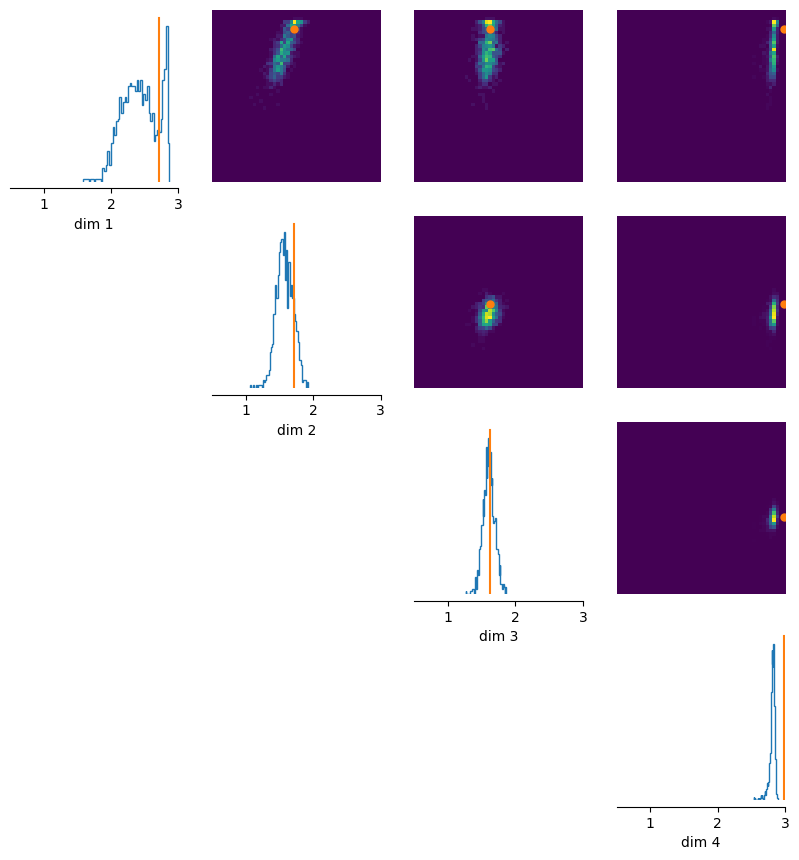

In [89]:
from sbi.analysis import pairplot
import numpy as np

pairplot(np.array(samples[:, -1, :]), points = np.array(np.array(theta_o)), limits = [[0.5,3.],[0.5,3.],[0.5,3.],[0.5,3.]])